In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("../data/Palo Alto Networks (1).csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


In [3]:
df.shape

(1470, 31)

In [4]:
df.columns.tolist()

['Age',
 'Attrition',
 'BusinessTravel',
 'DailyRate',
 'Department',
 'DistanceFromHome',
 'Education',
 'EducationField',
 'EnvironmentSatisfaction',
 'Gender',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobRole',
 'JobSatisfaction',
 'MaritalStatus',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'OverTime',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   int64
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EnvironmentSatisfaction   1470 non-null   int64
 9   Gender                    1470 non-null   str  
 10  HourlyRate                1470 non-null   int64
 11  JobInvolvement            1470 non-null   int64
 12  JobLevel                  1470 non-null   int64
 13  JobRole                   1470 non-null   str  
 14  JobSatisfaction           1470 non-null   int64
 15

In [6]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df["Attrition"].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

In [9]:
df["Attrition"].value_counts(normalize=True) * 100

Attrition
0    83.877551
1    16.122449
Name: proportion, dtype: float64

In [10]:
attrition_rate = df["Attrition"].mean() * 100

print(f"Overall Attrition Rate: {attrition_rate:.2f}%")

Overall Attrition Rate: 16.12%


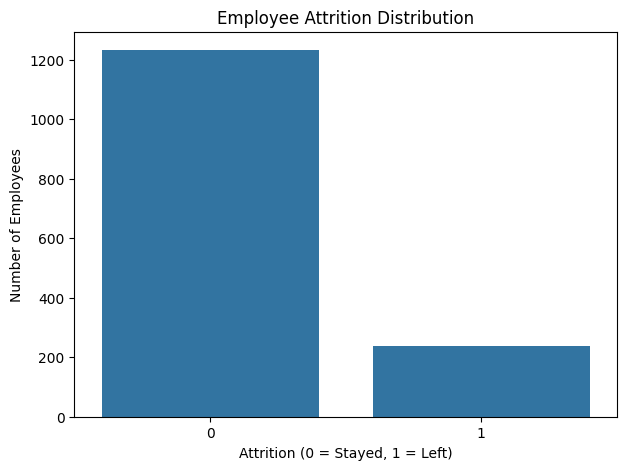

In [11]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Attrition")

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition (0 = Stayed, 1 = Left)")
plt.ylabel("Number of Employees")

plt.show()

In [13]:
attrition_summary = df["Attrition"].value_counts().reset_index()

attrition_summary.columns = ["Attrition", "Employee_Count"]

attrition_summary["Status"] = attrition_summary["Attrition"].map({
    0: "Stayed",
    1: "Left"
})

attrition_summary["Percentage"] = (
    attrition_summary["Employee_Count"] / len(df) * 100
).round(2)

attrition_summary

,Attrition,Employee_Count,Status,Percentage
0,0,1233,Stayed,83.88
1,1,237,Left,16.12


In [14]:
department_attrition = (
    df.groupby("Department")["Attrition"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

department_attrition

Department
Sales                     20.627803
Human Resources           19.047619
Research & Development    13.839750
Name: Attrition, dtype: float64

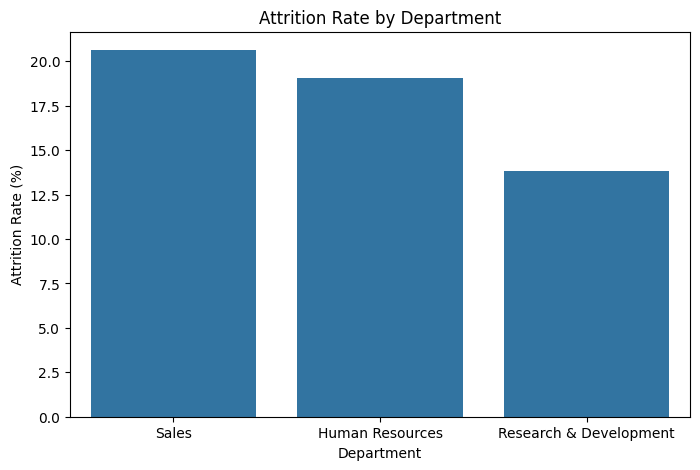

In [15]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=department_attrition.index,
    y=department_attrition.values
)

plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")

plt.show()

In [16]:
role_attrition = (
    df.groupby("JobRole")["Attrition"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

role_attrition

JobRole
Sales Representative         39.759036
Laboratory Technician        23.938224
Human Resources              23.076923
Sales Executive              17.484663
Research Scientist           16.095890
Manufacturing Director        6.896552
Healthcare Representative     6.870229
Manager                       4.901961
Research Director             2.500000
Name: Attrition, dtype: float64

In [17]:
overtime_attrition = (
    df.groupby("OverTime")["Attrition"]
    .mean()
    .mul(100)
)

overtime_attrition

OverTime
No     10.436433
Yes    30.528846
Name: Attrition, dtype: float64

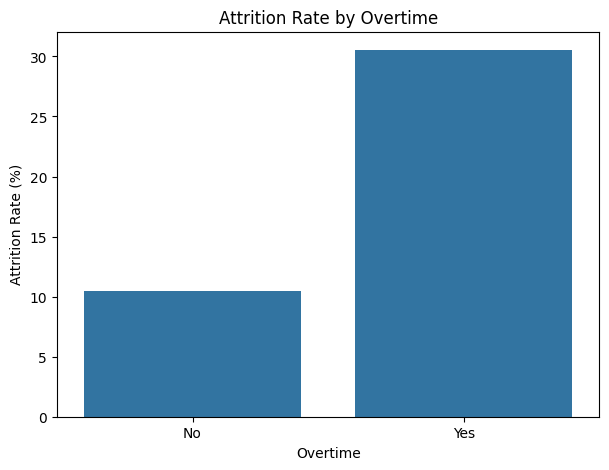

In [18]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=overtime_attrition.index,
    y=overtime_attrition.values
)

plt.title("Attrition Rate by Overtime")
plt.xlabel("Overtime")
plt.ylabel("Attrition Rate (%)")

plt.show()

In [19]:
satisfaction_attrition = (
    df.groupby("JobSatisfaction")["Attrition"]
    .mean()
    .mul(100)
)

satisfaction_attrition

JobSatisfaction
1    22.837370
2    16.428571
3    16.515837
4    11.328976
Name: Attrition, dtype: float64

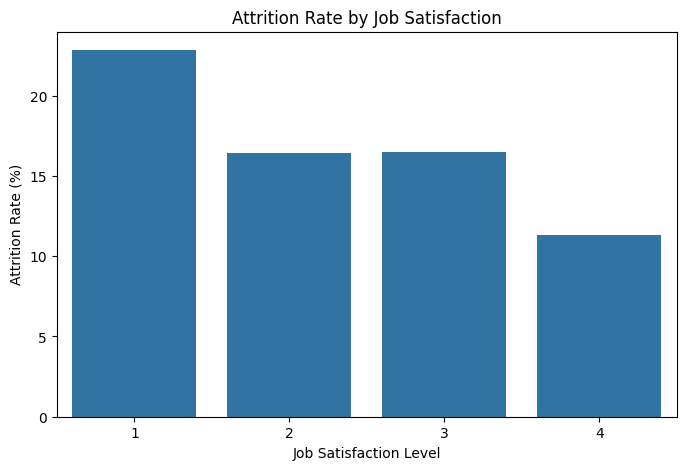

In [20]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=satisfaction_attrition.index,
    y=satisfaction_attrition.values
)

plt.title("Attrition Rate by Job Satisfaction")
plt.xlabel("Job Satisfaction Level")
plt.ylabel("Attrition Rate (%)")

plt.show()

In [21]:
wlb_attrition = (
    df.groupby("WorkLifeBalance")["Attrition"]
    .mean()
    .mul(100)
    .sort_index()
)

wlb_attrition

WorkLifeBalance
1    31.250000
2    16.860465
3    14.221725
4    17.647059
Name: Attrition, dtype: float64

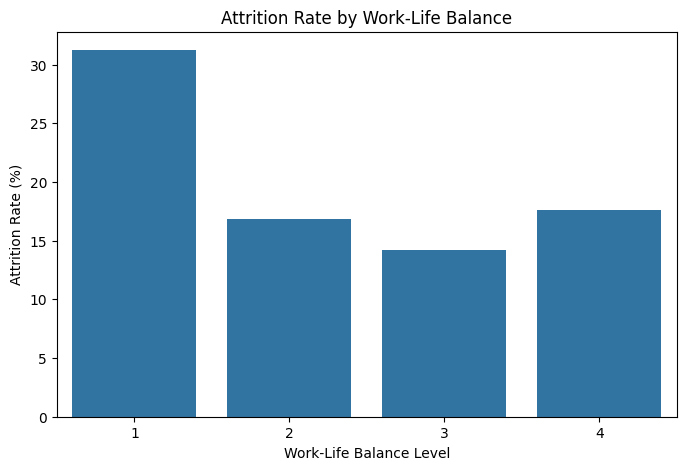

In [22]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=wlb_attrition.index,
    y=wlb_attrition.values
)

plt.title("Attrition Rate by Work-Life Balance")
plt.xlabel("Work-Life Balance Level")
plt.ylabel("Attrition Rate (%)")

plt.show()

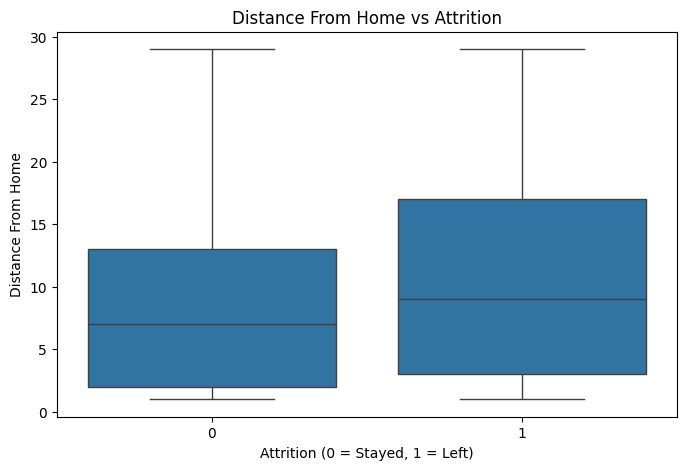

In [23]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Attrition",
    y="DistanceFromHome"
)

plt.title("Distance From Home vs Attrition")
plt.xlabel("Attrition (0 = Stayed, 1 = Left)")
plt.ylabel("Distance From Home")

plt.show()

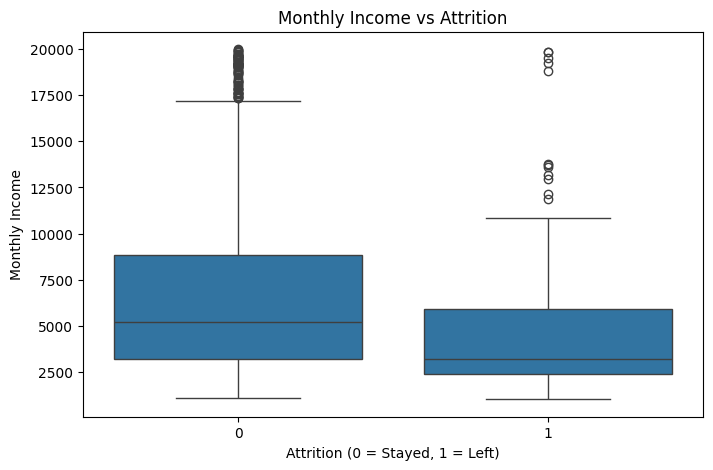

In [24]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Attrition",
    y="MonthlyIncome"
)

plt.title("Monthly Income vs Attrition")
plt.xlabel("Attrition (0 = Stayed, 1 = Left)")
plt.ylabel("Monthly Income")

plt.show()

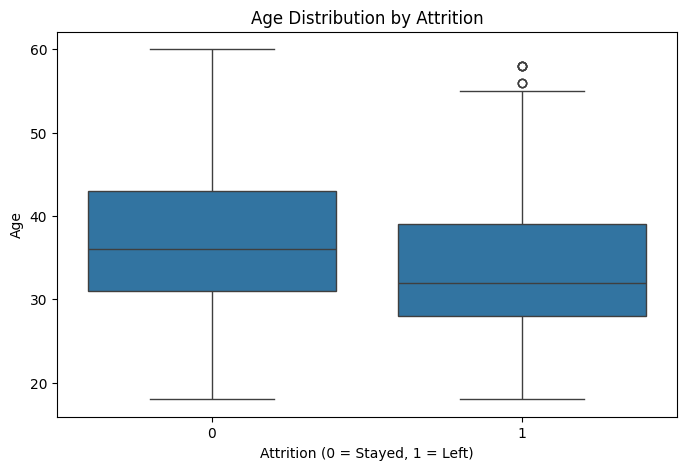

In [25]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Attrition",
    y="Age"
)

plt.title("Age Distribution by Attrition")
plt.xlabel("Attrition (0 = Stayed, 1 = Left)")
plt.ylabel("Age")

plt.show()

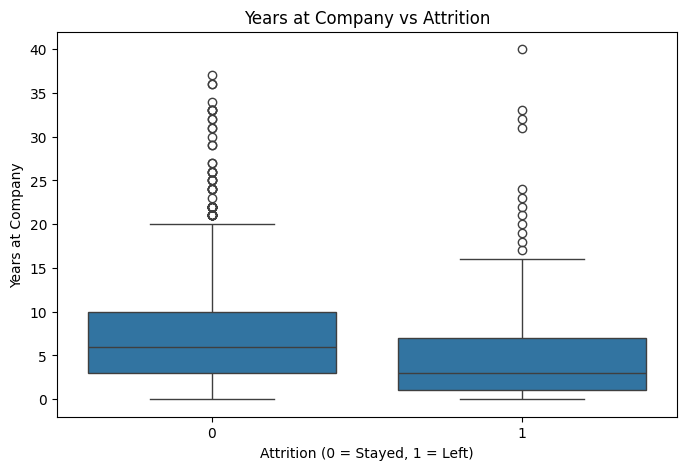

In [26]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Attrition",
    y="YearsAtCompany"
)

plt.title("Years at Company vs Attrition")
plt.xlabel("Attrition (0 = Stayed, 1 = Left)")
plt.ylabel("Years at Company")

plt.show()

In [27]:
promotion_attrition = (
    df.groupby("YearsSinceLastPromotion")["Attrition"]
    .mean()
    .mul(100)
)

promotion_attrition

YearsSinceLastPromotion
0     18.932874
1     13.725490
2     16.981132
3     17.307692
4      8.196721
5      4.444444
6     18.750000
7     21.052632
8      0.000000
9     23.529412
10    16.666667
11     8.333333
12     0.000000
13    20.000000
14    11.111111
15    23.076923
Name: Attrition, dtype: float64

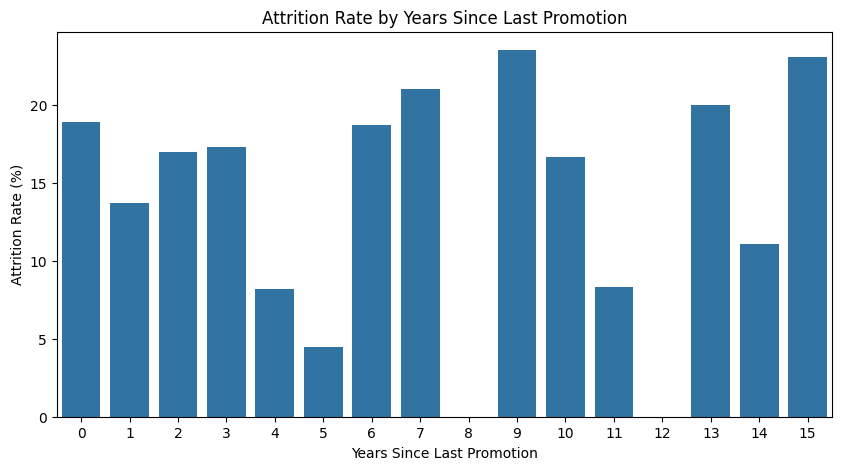

In [28]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=promotion_attrition.index,
    y=promotion_attrition.values
)

plt.title("Attrition Rate by Years Since Last Promotion")
plt.xlabel("Years Since Last Promotion")
plt.ylabel("Attrition Rate (%)")

plt.show()

In [29]:
training_attrition = (
    df.groupby("TrainingTimesLastYear")["Attrition"]
    .mean()
    .mul(100)
)

training_attrition

TrainingTimesLastYear
0    27.777778
1    12.676056
2    17.915905
3    14.052953
4    21.138211
5    11.764706
6     9.230769
Name: Attrition, dtype: float64

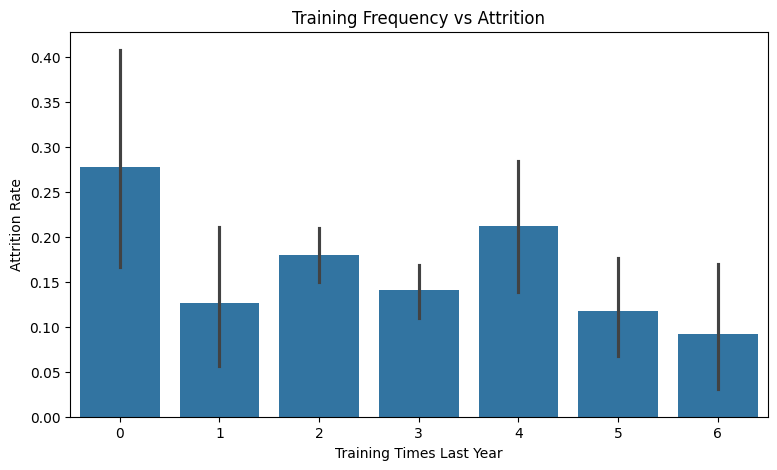

In [30]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=df,
    x="TrainingTimesLastYear",
    y="Attrition"
)

plt.title("Training Frequency vs Attrition")
plt.xlabel("Training Times Last Year")
plt.ylabel("Attrition Rate")

plt.show()

In [31]:
involvement_attrition = (
    df.groupby("JobInvolvement")["Attrition"]
    .mean()
    .mul(100)
)

involvement_attrition

JobInvolvement
1    33.734940
2    18.933333
3    14.400922
4     9.027778
Name: Attrition, dtype: float64

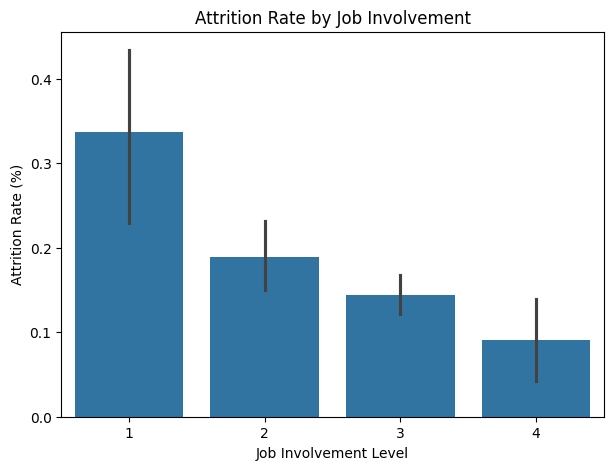

In [32]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df,
    x="JobInvolvement",
    y="Attrition"
)

plt.title("Attrition Rate by Job Involvement")
plt.xlabel("Job Involvement Level")
plt.ylabel("Attrition Rate (%)")

plt.show()

In [33]:
performance_attrition = (
    df.groupby("PerformanceRating")["Attrition"]
    .mean()
    .mul(100)
)

performance_attrition

PerformanceRating
3    16.077170
4    16.371681
Name: Attrition, dtype: float64

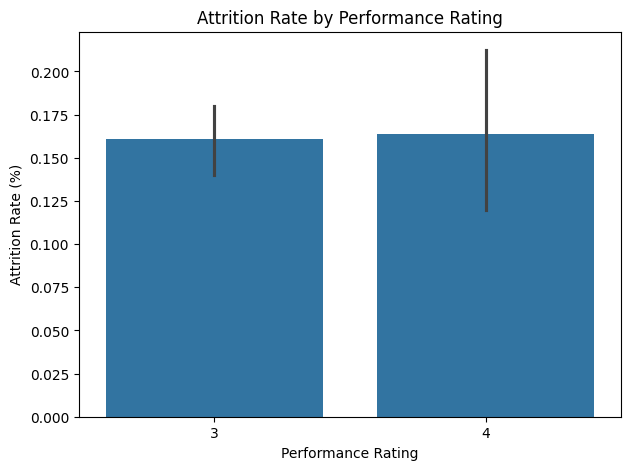

In [34]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df,
    x="PerformanceRating",
    y="Attrition"
)

plt.title("Attrition Rate by Performance Rating")
plt.xlabel("Performance Rating")
plt.ylabel("Attrition Rate (%)")

plt.show()

In [35]:
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

correlation

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
Age,1.000000,-0.159205,0.010661,-0.001686,0.208034,0.010146,0.024287,0.029820,0.509604,-0.004892,...,0.001904,0.053535,0.037510,0.680381,-0.019621,-0.021490,0.311309,0.212901,0.216513,0.202089
Attrition,-0.159205,1.000000,-0.056652,0.077924,-0.031373,-0.103369,-0.006846,-0.130016,-0.169105,-0.103481,...,0.002889,-0.045872,-0.137145,-0.171063,-0.059478,-0.063939,-0.134392,-0.160545,-0.033019,-0.156199
DailyRate,0.010661,-0.056652,1.000000,-0.004985,-0.016806,0.018355,0.023381,0.046135,0.002966,0.030571,...,0.000473,0.007846,0.042143,0.014515,0.002453,-0.037848,-0.034055,0.009932,-0.033229,-0.026363
DistanceFromHome,-0.001686,0.077924,-0.004985,1.000000,0.021042,-0.016075,0.031131,0.008783,0.005303,-0.003669,...,0.027110,0.006557,0.044872,0.004628,-0.036942,-0.026556,0.009508,0.018845,0.010029,0.014406
Education,0.208034,-0.031373,-0.016806,0.021042,1.000000,-0.027128,0.016775,0.042438,0.101589,-0.011296,...,-0.024539,-0.009118,0.018422,0.148280,-0.025100,0.009819,0.069114,0.060236,0.054254,0.069065
EnvironmentSatisfaction,0.010146,-0.103369,0.018355,-0.016075,-0.027128,1.000000,-0.049857,-0.008278,0.001212,-0.006784,...,-0.029548,0.007665,0.003432,-0.002693,-0.019359,0.027627,0.001458,0.018007,0.016194,-0.004999
HourlyRate,0.024287,-0.006846,0.023381,0.031131,0.016775,-0.049857,1.000000,0.042861,-0.027853,-0.071335,...,-0.002172,0.001330,0.050263,-0.002334,-0.008548,-0.004607,-0.019582,-0.024106,-0.026716,-0.020123
JobInvolvement,0.029820,-0.130016,0.046135,0.008783,0.042438,-0.008278,0.042861,1.000000,-0.012630,-0.021476,...,-0.029071,0.034297,0.021523,-0.005533,-0.015338,-0.014617,-0.021355,0.008717,-0.024184,0.025976
JobLevel,0.509604,-0.169105,0.002966,0.005303,0.101589,0.001212,-0.027853,-0.012630,1.000000,-0.001944,...,-0.021222,0.021642,0.013984,0.782208,-0.018191,0.037818,0.534739,0.389447,0.353885,0.375281
JobSatisfaction,-0.004892,-0.103481,0.030571,-0.003669,-0.011296,-0.006784,-0.071335,-0.021476,-0.001944,1.000000,...,0.002297,-0.012454,0.010690,-0.020185,-0.005779,-0.019459,-0.003803,-0.002305,-0.018214,-0.027656


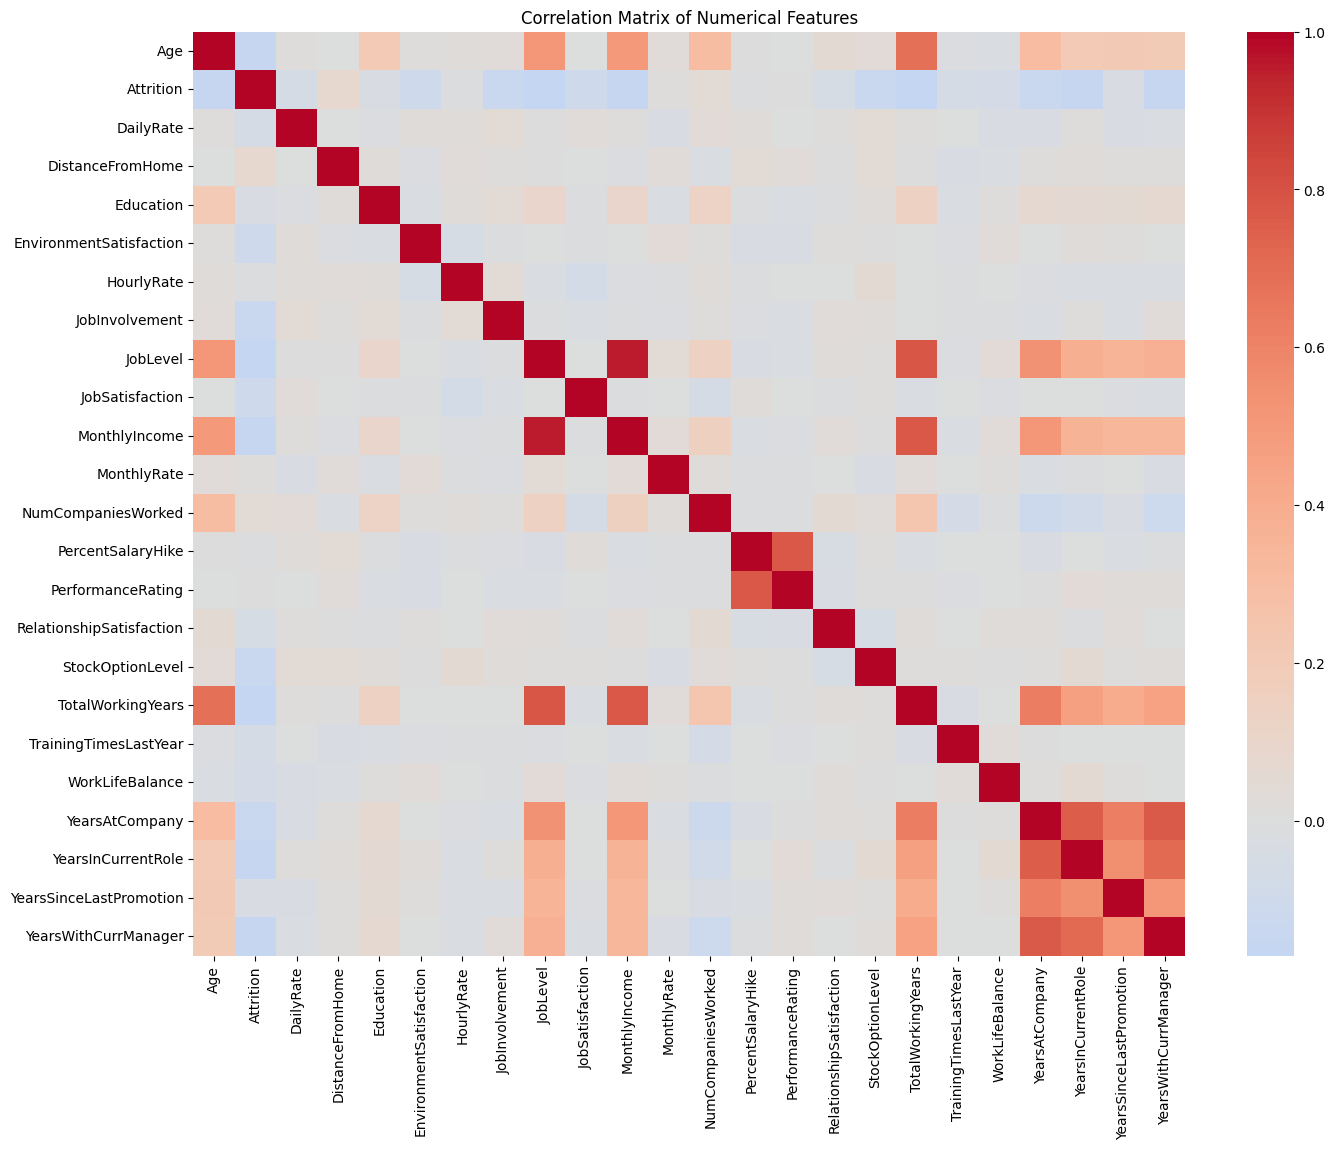

In [36]:
plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation,
    annot=False,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Features")

plt.show()

In [37]:
df["IncomeExperienceRatio"] = (
    df["MonthlyIncome"] / (df["TotalWorkingYears"] + 1)
)

df["PromotionDelay"] = (
    df["YearsSinceLastPromotion"] >= 3
).astype(int)

df["EngagementScore"] = (
    df[
        [
            "JobInvolvement",
            "JobSatisfaction",
            "EnvironmentSatisfaction",
            "RelationshipSatisfaction"
        ]
    ].mean(axis=1)
)

df["WorkloadStress"] = (
    (df["OverTime"] == "Yes") &
    (df["WorkLifeBalance"] <= 2)
).astype(int)

print("Feature engineering completed!")

Feature engineering completed!


In [38]:
df[
    [
        "IncomeExperienceRatio",
        "PromotionDelay",
        "EngagementScore",
        "WorkloadStress"
    ]
].head()

,IncomeExperienceRatio,PromotionDelay,EngagementScore,WorkloadStress
0,665.888889,0,2.50,1
1,466.363636,0,2.75,0
2,261.250000,0,2.75,0
3,323.222222,1,3.25,0
4,495.428571,0,2.50,0


In [39]:
df.shape

(1470, 35)

In [40]:
X = df.drop("Attrition", axis=1)

y = df["Attrition"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (1470, 34)
Target shape: (1470,)


In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1176, 34)
X_test: (294, 34)
y_train: (1176,)
y_test: (294,)


In [43]:
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Numerical Features:
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'IncomeExperienceRatio', 'PromotionDelay', 'EngagementScore', 'WorkloadStress']


C:\Users\SomyaAgrawal\AppData\Local\Temp\ipykernel_23056\3552009142.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


In [44]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

print("Preprocessing libraries imported successfully!")

Preprocessing libraries imported successfully!


In [45]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

print("Logistic Regression imported successfully!")

Logistic Regression imported successfully!


In [47]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

print("Logistic Regression pipeline created successfully!")

Logistic Regression pipeline created successfully!


In [48]:
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [49]:
y_pred_logistic = logistic_model.predict(X_test)

print("Predictions generated successfully!")
print(y_pred_logistic[:10])

Predictions generated successfully!
[0 0 0 0 1 1 0 0 0 0]


In [50]:
y_prob_logistic = logistic_model.predict_proba(X_test)[:, 1]

print("Attrition probabilities generated successfully!")
print(y_prob_logistic[:10])

Attrition probabilities generated successfully!
[0.31360772 0.02410285 0.46747271 0.02155738 0.76991733 0.78250171
 0.08536942 0.1569839  0.0186018  0.39941656]


In [51]:
logistic_results = pd.DataFrame({
    "Actual_Attrition": y_test.values,
    "Predicted_Attrition": y_pred_logistic,
    "Attrition_Probability": y_prob_logistic
})

logistic_results.head(10)

,Actual_Attrition,Predicted_Attrition,Attrition_Probability
0,0,0,0.313608
1,0,0,0.024103
2,0,0,0.467473
3,0,0,0.021557
4,1,1,0.769917
5,0,1,0.782502
6,0,0,0.085369
7,0,0,0.156984
8,0,0,0.018602
9,0,0,0.399417


In [52]:
logistic_results = pd.DataFrame({
    "Actual_Attrition": y_test.values,
    "Predicted_Attrition": y_pred_logistic,
    "Attrition_Probability": y_prob_logistic
})

logistic_results.head(10)

,Actual_Attrition,Predicted_Attrition,Attrition_Probability
0,0,0,0.313608
1,0,0,0.024103
2,0,0,0.467473
3,0,0,0.021557
4,1,1,0.769917
5,0,1,0.782502
6,0,0,0.085369
7,0,0,0.156984
8,0,0,0.018602
9,0,0,0.399417


In [53]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Evaluation metrics imported successfully!")

Evaluation metrics imported successfully!


In [54]:
accuracy = accuracy_score(y_test, y_pred_logistic)
precision = precision_score(y_test, y_pred_logistic)
recall = recall_score(y_test, y_pred_logistic)
f1 = f1_score(y_test, y_pred_logistic)
roc_auc = roc_auc_score(y_test, y_prob_logistic)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

Accuracy  : 0.7721
Precision : 0.3810
Recall    : 0.6809
F1 Score  : 0.4885
ROC-AUC   : 0.8061


In [55]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_logistic)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[195  52]
 [ 15  32]]


<Figure size 600x500 with 0 Axes>

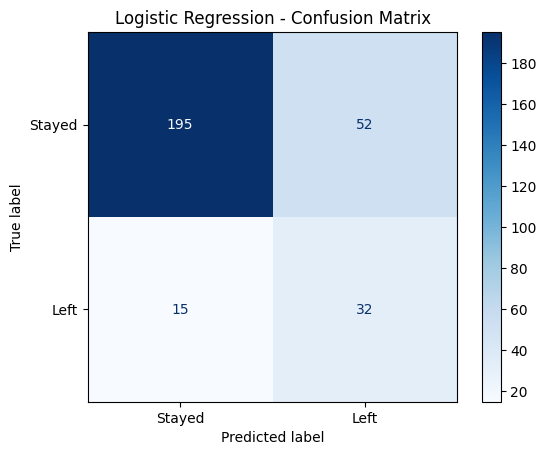

In [56]:
plt.figure(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Stayed", "Left"]
)

disp.plot(cmap="Blues")

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [57]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_logistic,
    target_names=["Stayed", "Left"]
))

              precision    recall  f1-score   support

      Stayed       0.93      0.79      0.85       247
        Left       0.38      0.68      0.49        47

    accuracy                           0.77       294
   macro avg       0.65      0.74      0.67       294
weighted avg       0.84      0.77      0.80       294



In [58]:
from sklearn.metrics import roc_curve, auc

In [59]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob_logistic
)

roc_auc = auc(fpr, tpr)

print(f"ROC-AUC: {roc_auc:.4f}")

ROC-AUC: 0.8061


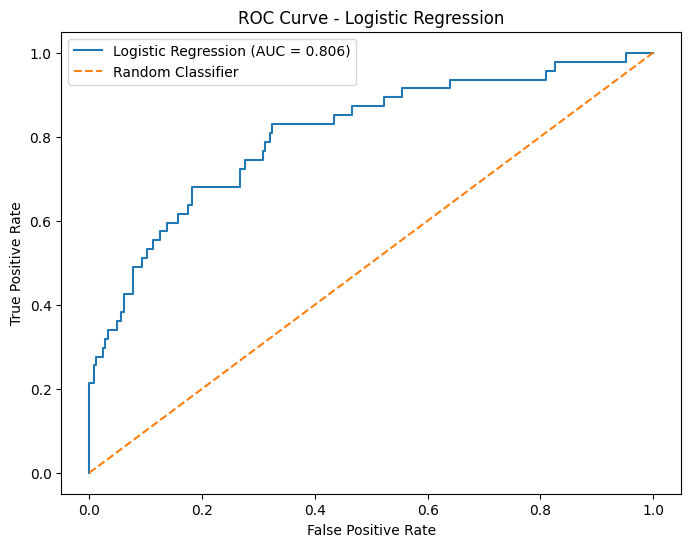

In [60]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

In [61]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

print("Random Forest libraries imported successfully!")

Random Forest libraries imported successfully!


In [62]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                class_weight="balanced"
            )
        )
    ]
)

print("Random Forest pipeline created successfully!")

Random Forest pipeline created successfully!


In [63]:
random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [64]:
y_pred_rf = random_forest_model.predict(X_test)

print("Random Forest predictions generated successfully!")
print(y_pred_rf[:10])

Random Forest predictions generated successfully!
[0 0 0 0 0 0 0 0 0 0]


In [65]:
print("Random Forest prediction counts:")
print(pd.Series(y_pred_rf).value_counts())

Random Forest prediction counts:
0    287
1      7
Name: count, dtype: int64


In [67]:
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

print("Random Forest attrition probabilities generated successfully!")
print(y_prob_rf[:20])

Random Forest attrition probabilities generated successfully!
[0.45333333 0.05666667 0.06       0.03333333 0.36333333 0.16333333
 0.1        0.07       0.01333333 0.33       0.05       0.13666667
 0.09666667 0.16666667 0.12666667 0.47       0.08       0.05
 0.26666667 0.04333333]


In [68]:
print("Number of probabilities:", len(y_prob_rf))
print("Minimum probability:", y_prob_rf.min())
print("Maximum probability:", y_prob_rf.max())

Number of probabilities: 294
Minimum probability: 0.006666666666666667
Maximum probability: 0.8266666666666667


In [69]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print(f"Accuracy  : {accuracy_rf:.4f}")
print(f"Precision : {precision_rf:.4f}")
print(f"Recall    : {recall_rf:.4f}")
print(f"F1 Score  : {f1_rf:.4f}")
print(f"ROC-AUC   : {roc_auc_rf:.4f}")

Accuracy  : 0.8503
Precision : 0.7143
Recall    : 0.1064
F1 Score  : 0.1852
ROC-AUC   : 0.7961


In [70]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Random Forest Confusion Matrix:")
print(cm_rf)

Random Forest Confusion Matrix:
[[245   2]
 [ 42   5]]


<Figure size 600x500 with 0 Axes>

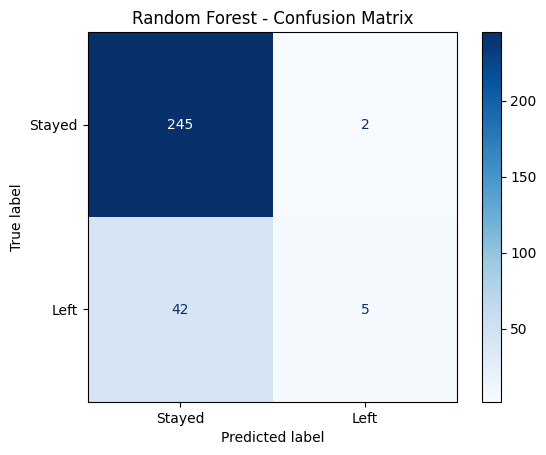

In [71]:
plt.figure(figsize=(6, 5))

disp_rf = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Stayed", "Left"]
)

disp_rf.plot(cmap="Blues")

plt.title("Random Forest - Confusion Matrix")
plt.show()

In [72]:
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=["Stayed", "Left"]
))

              precision    recall  f1-score   support

      Stayed       0.85      0.99      0.92       247
        Left       0.71      0.11      0.19        47

    accuracy                           0.85       294
   macro avg       0.78      0.55      0.55       294
weighted avg       0.83      0.85      0.80       294



In [73]:
import xgboost as xgb

print("XGBoost imported successfully!")

XGBoost imported successfully!


In [74]:
xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            xgb.XGBClassifier(
                n_estimators=300,
                max_depth=4,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                eval_metric="logloss"
            )
        )
    ]
)

print("XGBoost pipeline created successfully!")

XGBoost pipeline created successfully!


In [75]:
xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


In [76]:
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost predictions generated successfully!")
print(y_pred_xgb[:10])

XGBoost predictions generated successfully!
[0 0 0 0 0 0 0 0 0 0]


In [77]:
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost attrition probabilities generated successfully!")
print(y_prob_xgb[:10])

XGBoost attrition probabilities generated successfully!
[0.25885573 0.00772276 0.03400931 0.00195294 0.17417982 0.11664688
 0.03338274 0.01910668 0.00384402 0.34242257]


In [78]:
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print(f"Accuracy  : {accuracy_xgb:.4f}")
print(f"Precision : {precision_xgb:.4f}")
print(f"Recall    : {recall_xgb:.4f}")
print(f"F1 Score  : {f1_xgb:.4f}")
print(f"ROC-AUC   : {roc_auc_xgb:.4f}")

Accuracy  : 0.8571
Precision : 0.6316
Recall    : 0.2553
F1 Score  : 0.3636
ROC-AUC   : 0.7795


In [79]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        0.7721,
        0.8503,
        0.8571
    ],
    "Precision": [
        0.3810,
        0.7143,
        0.6316
    ],
    "Recall": [
        0.6809,
        0.1064,
        0.2553
    ],
    "F1 Score": [
        0.4885,
        0.1852,
        0.3636
    ],
    "ROC-AUC": [
        0.8061,
        0.7961,
        0.7795
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7721,0.3810,0.6809,0.4885,0.8061
1,Random Forest,0.8503,0.7143,0.1064,0.1852,0.7961
2,XGBoost,0.8571,0.6316,0.2553,0.3636,0.7795


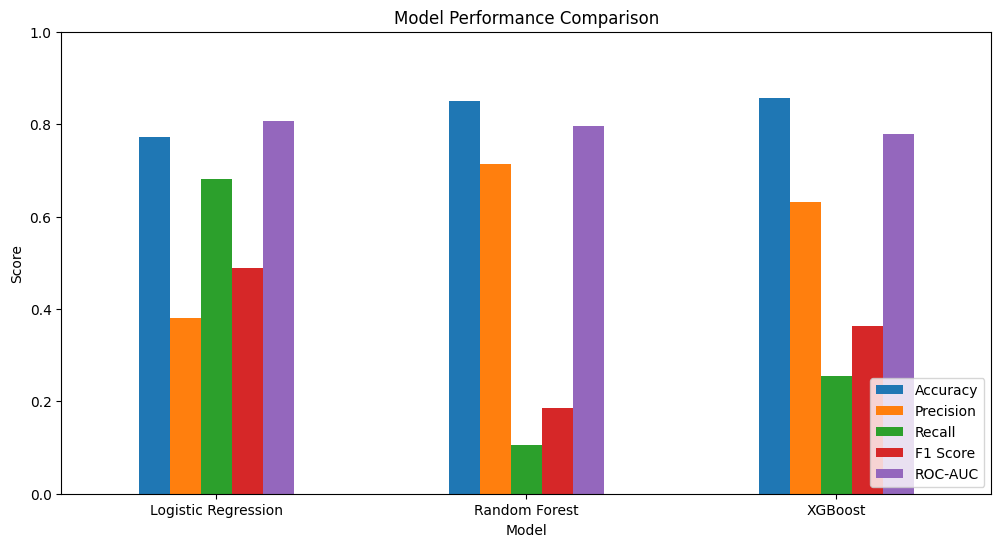

In [80]:
model_comparison.set_index("Model")[[
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]].plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

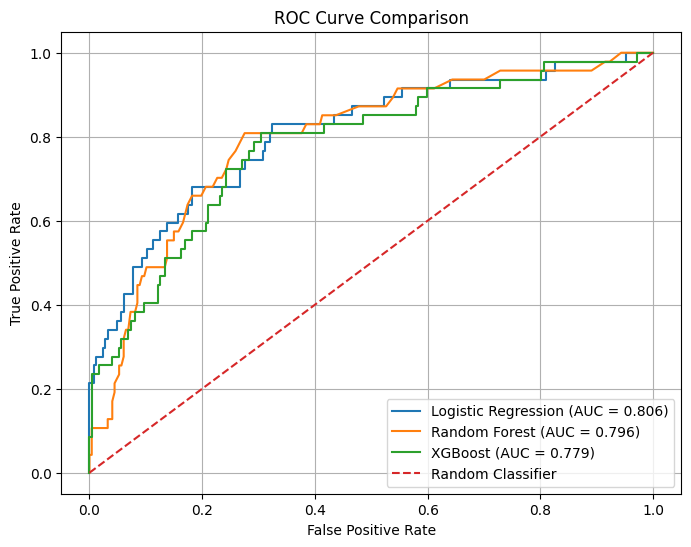

In [82]:
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate ROC curves
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_logistic)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

# Calculate AUC values directly
auc_log = roc_auc_score(y_test, y_prob_logistic)
auc_rf = roc_auc_score(y_test, y_prob_rf)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

# Plot
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_log,
    tpr_log,
    label=f"Logistic Regression (AUC = {auc_log:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {auc_rf:.3f})"
)

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f"XGBoost (AUC = {auc_xgb:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid()
plt.show()

In [83]:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

thresholds = np.arange(0.10, 0.91, 0.05)

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_prob_logistic >= threshold).astype(int)

    precision = precision_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    threshold_results.append({
        "Threshold": round(threshold, 2),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1 Score": round(f1, 4)
    })

threshold_results_df = pd.DataFrame(threshold_results)

threshold_results_df

,Threshold,Precision,Recall,F1 Score
0,0.10,0.2047,0.9362,0.3359
1,0.15,0.2205,0.9149,0.3554
2,0.20,0.2360,0.8936,0.3733
3,0.25,0.2614,0.8511,0.4000
4,0.30,0.2889,0.8298,0.4286
5,0.35,0.3217,0.7872,0.4568
6,0.40,0.3333,0.7447,0.4605
7,0.45,0.3368,0.6809,0.4507
8,0.50,0.3810,0.6809,0.4885
9,0.55,0.4054,0.6383,0.4959


In [84]:
best_threshold_row = threshold_results_df.loc[
    threshold_results_df["F1 Score"].idxmax()
]

best_threshold_row

Threshold    0.6000
Precision    0.4516
Recall       0.5957
F1 Score     0.5138
Name: 10, dtype: float64

In [85]:
best_threshold = best_threshold_row["Threshold"]

print("Best Threshold:", best_threshold)
print("Precision:", best_threshold_row["Precision"])
print("Recall:", best_threshold_row["Recall"])
print("F1 Score:", best_threshold_row["F1 Score"])

Best Threshold: 0.6
Precision: 0.4516
Recall: 0.5957
F1 Score: 0.5138


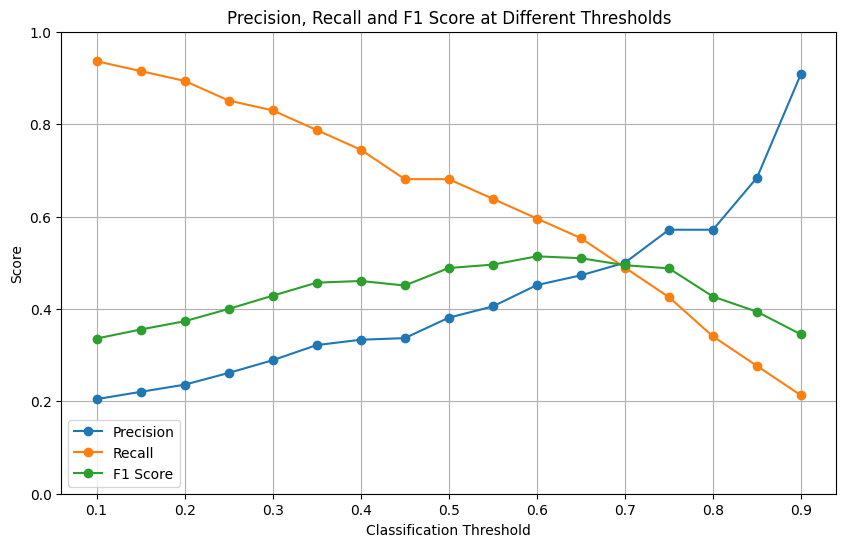

In [86]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall and F1 Score at Different Thresholds")
plt.ylim(0, 1)
plt.grid()
plt.legend()
plt.show()

In [87]:
y_pred_optimized = (
    y_prob_logistic >= best_threshold
).astype(int)

print("Optimized Classification Report")
print(
    classification_report(
        y_test,
        y_pred_optimized,
        target_names=["Stayed", "Left"]
    )
)

Optimized Classification Report
              precision    recall  f1-score   support

      Stayed       0.92      0.86      0.89       247
        Left       0.45      0.60      0.51        47

    accuracy                           0.82       294
   macro avg       0.68      0.73      0.70       294
weighted avg       0.84      0.82      0.83       294



In [88]:
risk_scores = y_prob_logistic

In [89]:
risk_category = pd.cut(
    risk_scores,
    bins=[0, 0.30, 0.60, 1.00],
    labels=["Low Risk", "Medium Risk", "High Risk"],
    include_lowest=True
)

risk_results = pd.DataFrame({
    "Employee_Index": X_test.index,
    "Attrition_Probability": risk_scores,
    "Risk_Category": risk_category,
    "Actual_Attrition": y_test.values
})

risk_results.head(10)

,Employee_Index,Attrition_Probability,Risk_Category,Actual_Attrition
0,1061,0.313608,Medium Risk,0
1,891,0.024103,Low Risk,0
2,456,0.467473,Medium Risk,0
3,922,0.021557,Low Risk,0
4,69,0.769917,High Risk,1
5,1164,0.782502,High Risk,0
6,406,0.085369,Low Risk,0
7,1330,0.156984,Low Risk,0
8,1232,0.018602,Low Risk,0
9,1311,0.399417,Medium Risk,0


In [90]:
best_threshold_row = threshold_results_df.loc[
    threshold_results_df["F1 Score"].idxmax()
]

best_threshold_row

Threshold    0.6000
Precision    0.4516
Recall       0.5957
F1 Score     0.5138
Name: 10, dtype: float64

In [91]:
best_threshold = best_threshold_row["Threshold"]

print("Best Threshold :", best_threshold)
print("Precision       :", best_threshold_row["Precision"])
print("Recall          :", best_threshold_row["Recall"])
print("F1 Score        :", best_threshold_row["F1 Score"])

Best Threshold : 0.6
Precision       : 0.4516
Recall          : 0.5957
F1 Score        : 0.5138


In [96]:
best_threshold = 0.60

y_pred_optimized = (
    y_prob_logistic >= best_threshold
).astype(int)

print("Optimized Classification Report")
print(
    classification_report(
        y_test,
        y_pred_optimized,
        target_names=["Stayed", "Left"]
    )
)

Optimized Classification Report
              precision    recall  f1-score   support

      Stayed       0.92      0.86      0.89       247
        Left       0.45      0.60      0.51        47

    accuracy                           0.82       294
   macro avg       0.68      0.73      0.70       294
weighted avg       0.84      0.82      0.83       294



In [97]:
risk_distribution = risk_results["Risk_Category"].value_counts()

print("Risk Category Counts:")
print(risk_distribution)

print("\nRisk Category Percentages:")
print(
    risk_results["Risk_Category"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Risk Category Counts:
Risk_Category
Low Risk       159
Medium Risk     73
High Risk       62
Name: count, dtype: int64

Risk Category Percentages:
Risk_Category
Low Risk       54.08
Medium Risk    24.83
High Risk      21.09
Name: proportion, dtype: float64


In [98]:
risk_validation = (
    risk_results
    .groupby("Risk_Category", observed=False)["Actual_Attrition"]
    .agg(
        Employees="count",
        Attrition_Count="sum",
        Attrition_Rate="mean"
    )
)

risk_validation["Attrition_Rate"] = (
    risk_validation["Attrition_Rate"] * 100
).round(2)

risk_validation

,Employees,Attrition_Count,Attrition_Rate
Risk_Category,,,
Low Risk,159,8,5.03
Medium Risk,73,11,15.07
High Risk,62,28,45.16


In [95]:
risk_validation = (
    risk_results
    .groupby("Risk_Category", observed=False)["Actual_Attrition"]
    .agg(
        Employees="count",
        Attrition_Count="sum",
        Attrition_Rate="mean"
    )
)

risk_validation["Attrition_Rate"] = (
    risk_validation["Attrition_Rate"] * 100
).round(2)

risk_validation

,Employees,Attrition_Count,Attrition_Rate
Risk_Category,,,
Low Risk,159,8,5.03
Medium Risk,73,11,15.07
High Risk,62,28,45.16


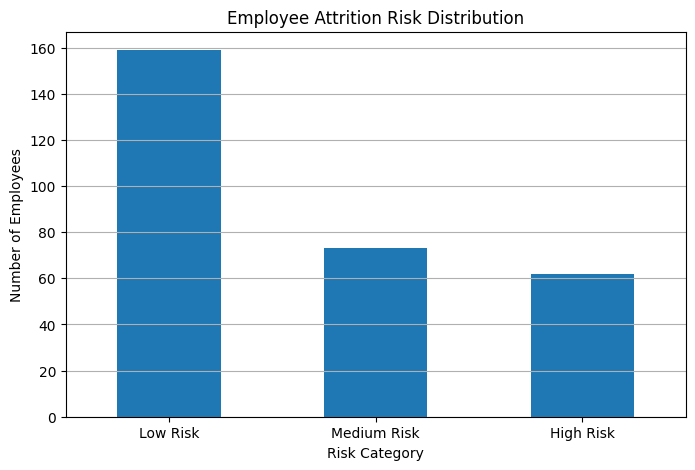

In [99]:
risk_counts = risk_results["Risk_Category"].value_counts()

plt.figure(figsize=(8, 5))

risk_counts.plot(kind="bar")

plt.title("Employee Attrition Risk Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Number of Employees")
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.show()

In [100]:
# Get the fitted preprocessor
fitted_preprocessor = logistic_model.named_steps["preprocessor"]

# Get the fitted logistic regression classifier
logistic_classifier = logistic_model.named_steps["classifier"]

# Get feature names after preprocessing
feature_names = fitted_preprocessor.get_feature_names_out()

# Get coefficients
coefficients = logistic_classifier.coef_[0]

# Create feature importance dataframe
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Calculate absolute importance
feature_importance["Absolute_Importance"] = (
    feature_importance["Coefficient"].abs()
)

# Sort by importance
feature_importance = feature_importance.sort_values(
    "Absolute_Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Coefficient,Absolute_Importance
46,cat__JobRole_Research Director,-1.336266,1.336266
43,cat__JobRole_Laboratory Technician,1.121627,1.121627
27,cat__BusinessTravel_Non-Travel,-1.064556,1.064556
49,cat__JobRole_Sales Representative,1.061049,1.061049
53,cat__OverTime_No,-0.870264,0.870264
28,cat__BusinessTravel_Travel_Frequently,0.830074,0.830074
37,cat__EducationField_Other,-0.764566,0.764566
54,cat__OverTime_Yes,0.733981,0.733981
33,cat__EducationField_Human Resources,0.728979,0.728979
41,cat__JobRole_Healthcare Representative,-0.645443,0.645443


In [101]:
top_features = feature_importance.head(15)

top_features

,Feature,Coefficient,Absolute_Importance
46,cat__JobRole_Research Director,-1.336266,1.336266
43,cat__JobRole_Laboratory Technician,1.121627,1.121627
27,cat__BusinessTravel_Non-Travel,-1.064556,1.064556
49,cat__JobRole_Sales Representative,1.061049,1.061049
53,cat__OverTime_No,-0.870264,0.870264
28,cat__BusinessTravel_Travel_Frequently,0.830074,0.830074
37,cat__EducationField_Other,-0.764566,0.764566
54,cat__OverTime_Yes,0.733981,0.733981
33,cat__EducationField_Human Resources,0.728979,0.728979
41,cat__JobRole_Healthcare Representative,-0.645443,0.645443


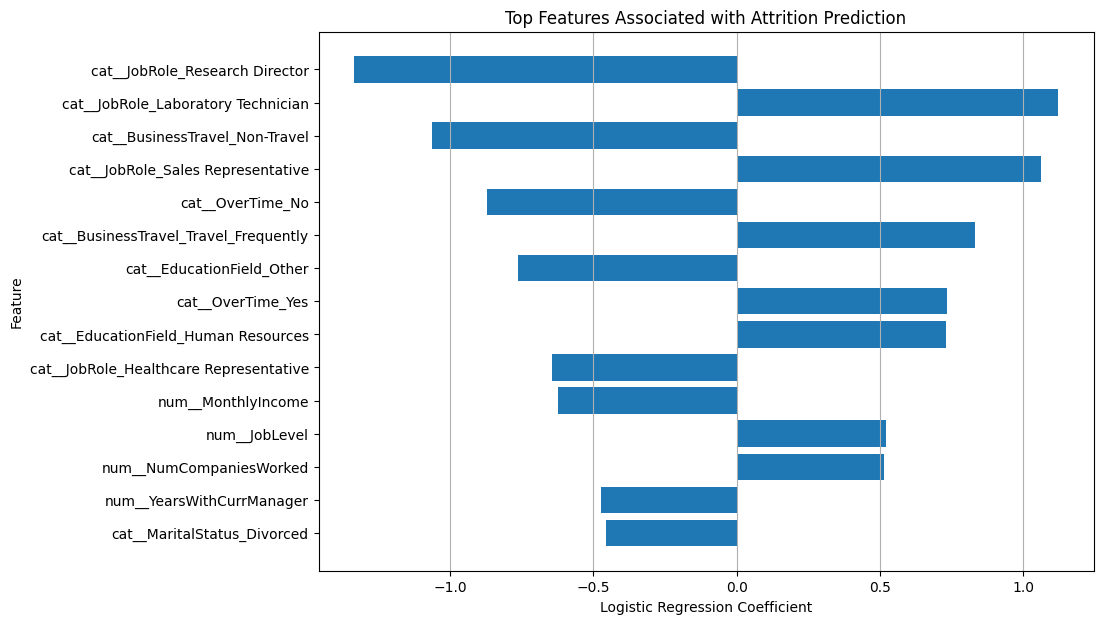

In [102]:
plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Top Features Associated with Attrition Prediction")
plt.gca().invert_yaxis()
plt.grid(axis="x")

plt.show()

In [104]:
feature_importance.head(15)



,Feature,Coefficient,Absolute_Importance
46,cat__JobRole_Research Director,-1.336266,1.336266
43,cat__JobRole_Laboratory Technician,1.121627,1.121627
27,cat__BusinessTravel_Non-Travel,-1.064556,1.064556
49,cat__JobRole_Sales Representative,1.061049,1.061049
53,cat__OverTime_No,-0.870264,0.870264
28,cat__BusinessTravel_Travel_Frequently,0.830074,0.830074
37,cat__EducationField_Other,-0.764566,0.764566
54,cat__OverTime_Yes,0.733981,0.733981
33,cat__EducationField_Human Resources,0.728979,0.728979
41,cat__JobRole_Healthcare Representative,-0.645443,0.645443


In [105]:
top_features_clean = feature_importance.head(15).copy()

top_features_clean["Direction"] = np.where(
    top_features_clean["Coefficient"] > 0,
    "Higher Attrition Risk",
    "Lower Attrition Risk"
)

top_features_clean["Coefficient"] = top_features_clean["Coefficient"].round(3)
top_features_clean["Absolute_Importance"] = (
    top_features_clean["Absolute_Importance"].round(3)
)

top_features_clean[
    ["Feature", "Coefficient", "Absolute_Importance", "Direction"]
]

,Feature,Coefficient,Absolute_Importance,Direction
46,cat__JobRole_Research Director,-1.336,1.336,Lower Attrition Risk
43,cat__JobRole_Laboratory Technician,1.122,1.122,Higher Attrition Risk
27,cat__BusinessTravel_Non-Travel,-1.065,1.065,Lower Attrition Risk
49,cat__JobRole_Sales Representative,1.061,1.061,Higher Attrition Risk
53,cat__OverTime_No,-0.870,0.870,Lower Attrition Risk
28,cat__BusinessTravel_Travel_Frequently,0.830,0.830,Higher Attrition Risk
37,cat__EducationField_Other,-0.765,0.765,Lower Attrition Risk
54,cat__OverTime_Yes,0.734,0.734,Higher Attrition Risk
33,cat__EducationField_Human Resources,0.729,0.729,Higher Attrition Risk
41,cat__JobRole_Healthcare Representative,-0.645,0.645,Lower Attrition Risk


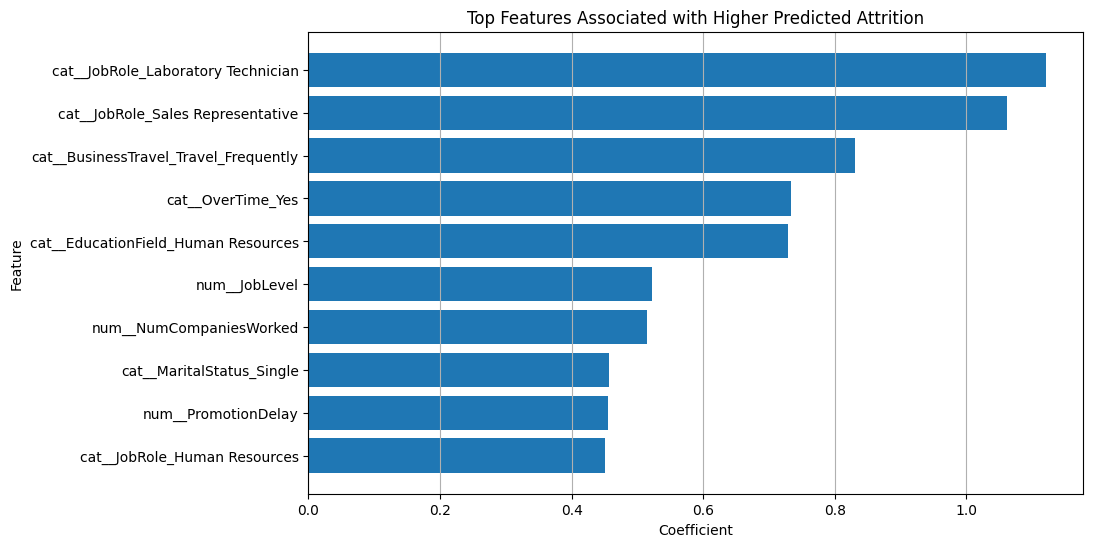

In [106]:
positive_features = (
    feature_importance[feature_importance["Coefficient"] > 0]
    .head(10)
    .sort_values("Coefficient")
)

plt.figure(figsize=(10, 6))

plt.barh(
    positive_features["Feature"],
    positive_features["Coefficient"]
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Top Features Associated with Higher Predicted Attrition")
plt.grid(axis="x")

plt.show()

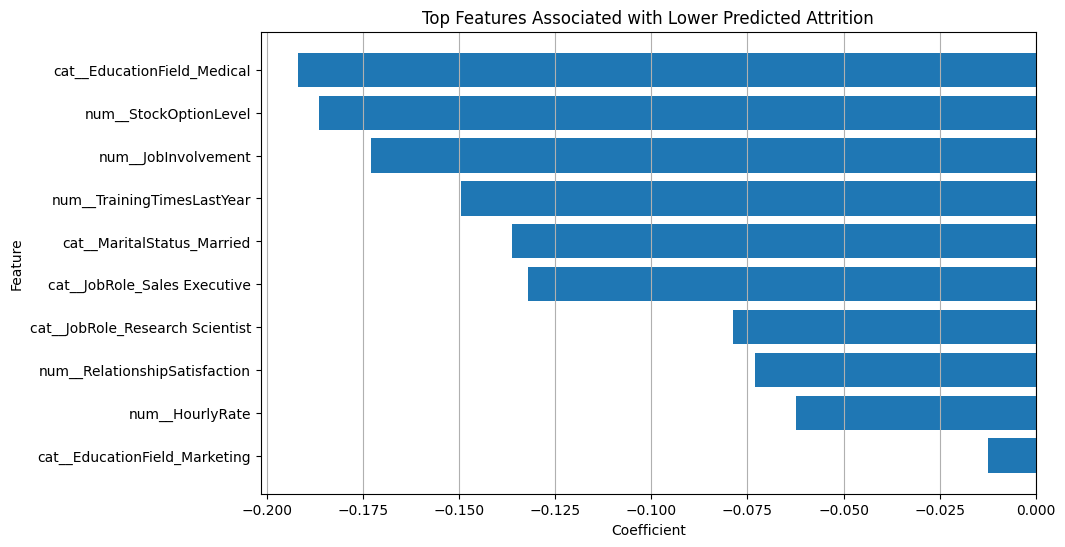

In [107]:
negative_features = (
    feature_importance[feature_importance["Coefficient"] < 0]
    .copy()

)

negative_features["Absolute_Importance"] = (
    negative_features["Coefficient"].abs()
)

negative_features = (
    negative_features
    .sort_values("Absolute_Importance")
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.barh(
    negative_features["Feature"],
    negative_features["Coefficient"]
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Top Features Associated with Lower Predicted Attrition")
plt.grid(axis="x")

plt.show()

In [108]:
feature_importance.to_csv(
    "../reports/feature_importance.csv",
    index=False
)

print("Feature importance saved successfully.")

Feature importance saved successfully.


In [110]:
def generate_reason_codes(employee):

    reasons = []

    if employee["OverTime"] == "Yes":
        reasons.append("Overtime")

    if employee["BusinessTravel"] == "Travel_Frequently":
        reasons.append("Frequent business travel")

    if employee["JobSatisfaction"] <= 2:
        reasons.append("Low job satisfaction")

    if employee["EnvironmentSatisfaction"] <= 2:
        reasons.append("Low environment satisfaction")

    if employee["WorkLifeBalance"] <= 2:
        reasons.append("Low work-life balance")

    if employee["DistanceFromHome"] >= 15:
        reasons.append("Long distance from home")

    if employee["YearsSinceLastPromotion"] >= 3:
        reasons.append("Long time since last promotion")

    if employee["YearsWithCurrManager"] <= 1:
        reasons.append("Short tenure with current manager")

    if employee["NumCompaniesWorked"] >= 4:
        reasons.append("Multiple previous employers")

    return reasons

In [111]:
test_employee = X_test.iloc[0]

reasons = generate_reason_codes(test_employee)

print("Employee Index:", X_test.index[0])
print("Potential Contributing Factors:")

for reason in reasons:
    print("-", reason)

Employee Index: 1061
Potential Contributing Factors:
- Low job satisfaction
- Short tenure with current manager


In [112]:
employee_index = X_test.index[0]

employee_probability = risk_results.loc[
    risk_results["Employee_Index"] == employee_index,
    "Attrition_Probability"
].iloc[0]

employee_risk = risk_results.loc[
    risk_results["Employee_Index"] == employee_index,
    "Risk_Category"
].iloc[0]

employee_reasons = generate_reason_codes(
    X_test.loc[employee_index]
)

print("========== EMPLOYEE RISK PROFILE ==========")
print("Employee Index:", employee_index)
print("Attrition Probability:", round(employee_probability * 100, 2), "%")
print("Risk Category:", employee_risk)
print("\nPotential Contributing Factors:")

for reason in employee_reasons:
    print("-", reason)

========== EMPLOYEE RISK PROFILE ==========
Employee Index: 1061
Attrition Probability: 31.36 %
Risk Category: Medium Risk

Potential Contributing Factors:
- Low job satisfaction
- Short tenure with current manager


In [113]:
import shap

print("SHAP version:", shap.__version__)

C:\Users\SomyaAgrawal\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP version: 0.51.0


In [114]:
# Get the fitted preprocessing pipeline
fitted_preprocessor = logistic_model.named_steps["preprocessor"]

# Transform the test data
X_test_transformed = fitted_preprocessor.transform(X_test)

# Get the transformed feature names
feature_names = fitted_preprocessor.get_feature_names_out()

print("Original test data shape:", X_test.shape)
print("Transformed test data shape:", X_test_transformed.shape)
print("Number of feature names:", len(feature_names))

Original test data shape: (294, 34)
Transformed test data shape: (294, 55)
Number of feature names: 55


In [115]:
fitted_preprocessor = logistic_model.named_steps["preprocessor"]

X_test_transformed = fitted_preprocessor.transform(X_test)

feature_names = fitted_preprocessor.get_feature_names_out()

print("Original test data shape:", X_test.shape)
print("Transformed test data shape:", X_test_transformed.shape)
print("Number of feature names:", len(feature_names))

Original test data shape: (294, 34)
Transformed test data shape: (294, 55)
Number of feature names: 55


In [116]:
logistic_classifier = logistic_model.named_steps["classifier"]

explainer = shap.LinearExplainer(
    logistic_classifier,
    X_test_transformed
)

print("SHAP explainer created successfully.")

SHAP explainer created successfully.


In [117]:
shap_values = explainer.shap_values(X_test_transformed)

print("SHAP values calculated successfully.")
print("SHAP values shape:", shap_values.shape)

SHAP values calculated successfully.
SHAP values shape: (294, 55)


In [118]:
employee_index = 1061

employee_position = X_test.index.get_loc(employee_index)

print("Employee Index:", employee_index)
print("Position in test data:", employee_position)

Employee Index: 1061
Position in test data: 0


In [119]:
employee_shap = pd.DataFrame({
    "Feature": feature_names,
    "SHAP_Value": shap_values[employee_position]
})

employee_shap["Absolute_SHAP"] = employee_shap["SHAP_Value"].abs()

employee_shap = employee_shap.sort_values(
    "Absolute_SHAP",
    ascending=False
)

employee_shap.head(15)

,Feature,SHAP_Value,Absolute_SHAP
49,cat__JobRole_Sales Representative,0.986775,0.986775
27,cat__BusinessTravel_Non-Travel,-0.968746,0.968746
9,num__MonthlyIncome,0.580009,0.580009
7,num__JobLevel,-0.487831,0.487831
23,num__IncomeExperienceRatio,0.464912,0.464912
22,num__YearsWithCurrManager,0.460391,0.460391
11,num__NumCompaniesWorked,-0.405247,0.405247
16,num__TotalWorkingYears,0.345174,0.345174
0,num__Age,0.329547,0.329547
19,num__YearsAtCompany,-0.300055,0.300055


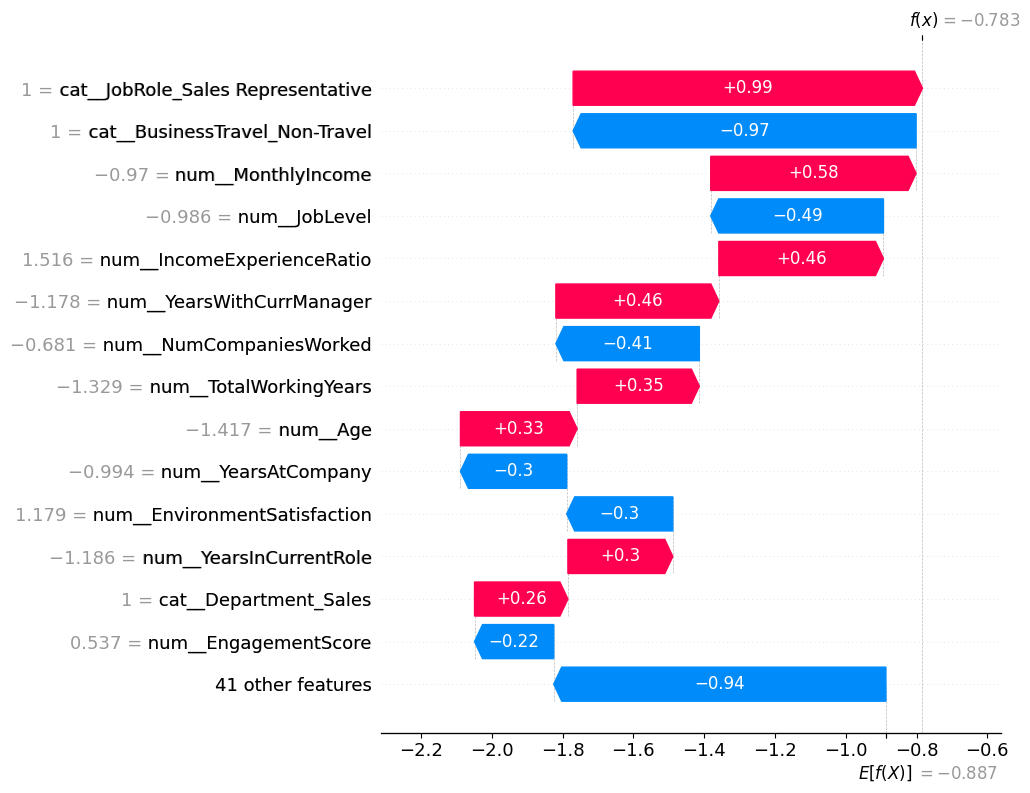

In [120]:
employee_explanation = shap.Explanation(
    values=shap_values[employee_position],
    base_values=explainer.expected_value,
    data=X_test_transformed[employee_position],
    feature_names=feature_names
)

shap.plots.waterfall(
    employee_explanation,
    max_display=15
)

In [121]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)

global_shap_importance = pd.DataFrame({
    "Feature": feature_names,
    "Mean_Absolute_SHAP": mean_abs_shap
})

global_shap_importance = global_shap_importance.sort_values(
    "Mean_Absolute_SHAP",
    ascending=False
)

global_shap_importance.head(20)

,Feature,Mean_Absolute_SHAP
9,num__MonthlyIncome,0.501205
11,num__NumCompaniesWorked,0.438498
7,num__JobLevel,0.411504
22,num__YearsWithCurrManager,0.379505
24,num__PromotionDelay,0.366672
53,cat__OverTime_No,0.330049
43,cat__JobRole_Laboratory Technician,0.309325
54,cat__OverTime_Yes,0.278364
25,num__EngagementScore,0.271008
23,num__IncomeExperienceRatio,0.255937


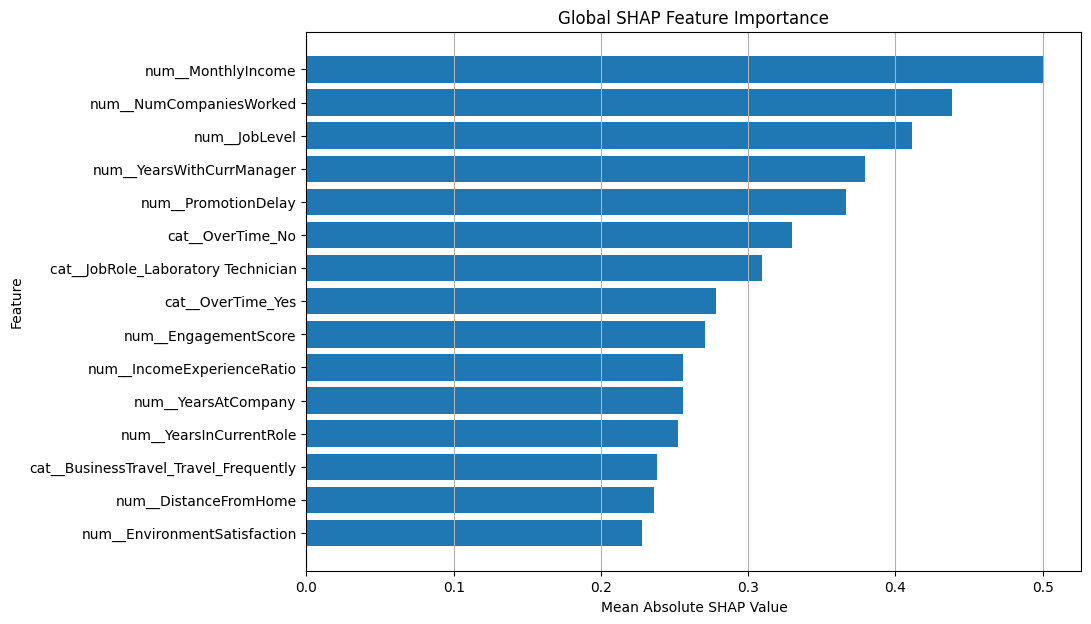

In [122]:
plt.figure(figsize=(10, 7))

top_shap = global_shap_importance.head(15).sort_values(
    "Mean_Absolute_SHAP"
)

plt.barh(
    top_shap["Feature"],
    top_shap["Mean_Absolute_SHAP"]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title("Global SHAP Feature Importance")

plt.grid(axis="x")
plt.show()

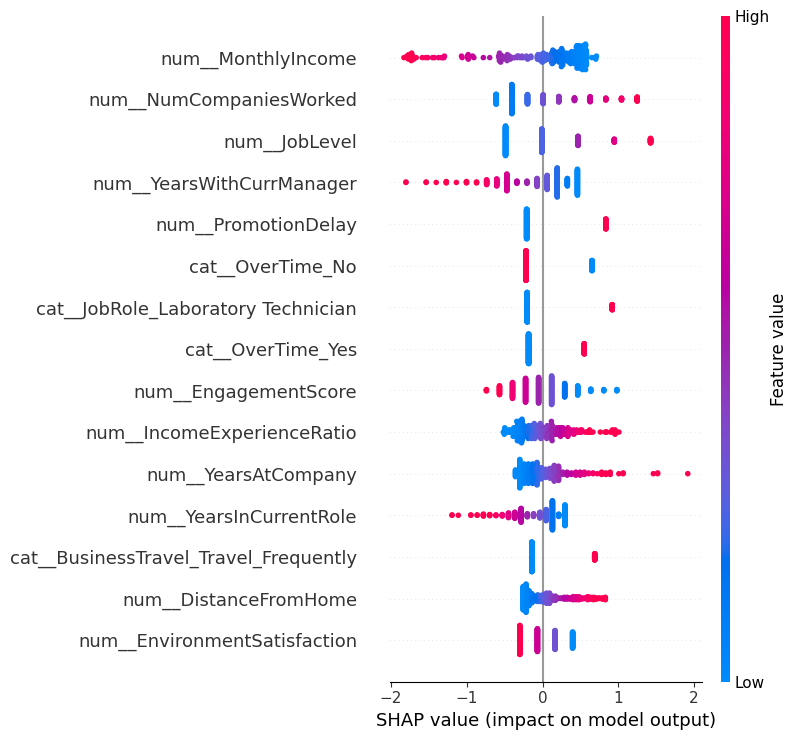

In [123]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    max_display=15
)

In [124]:
global_shap_importance.to_csv(
    "../reports/shap_global_importance.csv",
    index=False
)

employee_shap.to_csv(
    "../reports/shap_employee_1061.csv",
    index=False
)

print("SHAP results saved successfully.")

SHAP results saved successfully.


In [125]:
import joblib

joblib.dump(
    logistic_model,
    "../models/logistic_attrition_model.pkl"
)

print("Final Logistic Regression model saved successfully.")

Final Logistic Regression model saved successfully.


In [126]:
risk_threshold = 0.60

joblib.dump(
    risk_threshold,
    "../models/risk_threshold.pkl"
)

print("Risk threshold saved:", risk_threshold)

Risk threshold saved: 0.6


In [127]:
model_metadata = {
    "categorical_features": categorical_features,
    "numerical_features": numerical_features,
    "risk_threshold": risk_threshold,
    "risk_bands": {
        "Low Risk": "< 0.30",
        "Medium Risk": "0.30 - 0.60",
        "High Risk": "> 0.60"
    }
}

joblib.dump(
    model_metadata,
    "../models/model_metadata.pkl"
)

print("Model metadata saved successfully.")

Model metadata saved successfully.


In [128]:
def predict_attrition_risk(employee_data):

    employee_df = pd.DataFrame([employee_data])

    probability = logistic_model.predict_proba(
        employee_df
    )[0, 1]

    if probability < 0.30:
        risk_category = "Low Risk"

    elif probability <= 0.60:
        risk_category = "Medium Risk"

    else:
        risk_category = "High Risk"

    return probability, risk_category

In [129]:
employee_1061 = X_test.loc[1061].to_dict()

probability, risk_category = predict_attrition_risk(
    employee_1061
)

print("Employee Index: 1061")
print("Attrition Probability:", round(probability * 100, 2), "%")
print("Risk Category:", risk_category)

Employee Index: 1061
Attrition Probability: 31.36 %
Risk Category: Medium Risk


In [130]:
all_probabilities = logistic_model.predict_proba(X)[:, 1]

all_risk_categories = pd.cut(
    all_probabilities,
    bins=[0, 0.30, 0.60, 1.00],
    labels=["Low Risk", "Medium Risk", "High Risk"],
    include_lowest=True
)

final_predictions = df.copy()

final_predictions["Attrition_Probability"] = all_probabilities

final_predictions["Risk_Category"] = all_risk_categories

final_predictions.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,IncomeExperienceRatio,PromotionDelay,EngagementScore,WorkloadStress,Attrition_Probability,Risk_Category
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,6,4,0,5,665.888889,0,2.50,1,0.910742,High Risk
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,10,7,1,7,466.363636,0,2.75,0,0.078484,Low Risk
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,0,0,0,0,261.250000,0,2.75,0,0.719457,High Risk
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,8,7,3,0,323.222222,1,3.25,0,0.497894,Medium Risk
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,2,2,2,2,495.428571,0,2.50,0,0.784310,High Risk


In [131]:
final_predictions.to_csv(
    "../reports/employee_risk_scores.csv",
    index=False
)

print("Employee risk scoring dataset saved successfully.")

Employee risk scoring dataset saved successfully.


In [132]:
risk_distribution = (
    final_predictions["Risk_Category"]
    .value_counts()
    .reindex(["Low Risk", "Medium Risk", "High Risk"])
)

print(risk_distribution)

Risk_Category
Low Risk       772
Medium Risk    364
High Risk      334
Name: count, dtype: int64


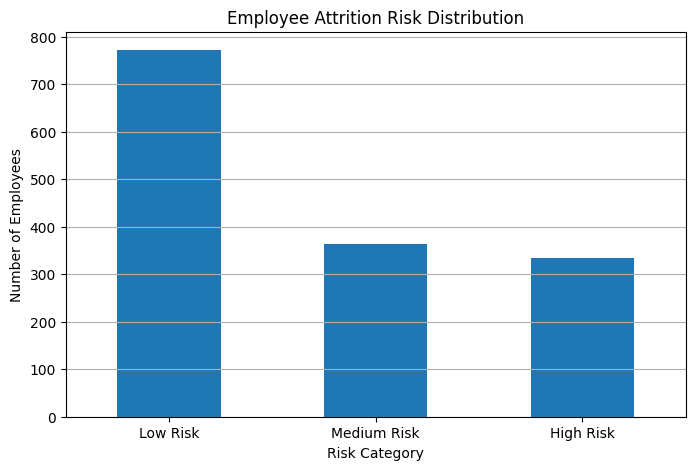

In [133]:
plt.figure(figsize=(8, 5))

risk_distribution.plot(kind="bar")

plt.xlabel("Risk Category")
plt.ylabel("Number of Employees")
plt.title("Employee Attrition Risk Distribution")

plt.xticks(rotation=0)
plt.grid(axis="y")

plt.show()

In [134]:
import streamlit

print("Streamlit version:", streamlit.__version__)

Streamlit version: 1.57.0


In [135]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.51.0


In [136]:
# Get the fitted preprocessing component
fitted_preprocessor = logistic_model.named_steps["preprocessor"]

# Transform the test data
X_test_transformed = fitted_preprocessor.transform(X_test)

# Get transformed feature names
feature_names = fitted_preprocessor.get_feature_names_out()

print("Original test data shape:", X_test.shape)
print("Transformed test data shape:", X_test_transformed.shape)
print("Number of feature names:", len(feature_names))

Original test data shape: (294, 34)
Transformed test data shape: (294, 55)
Number of feature names: 55


In [137]:
logistic_classifier = logistic_model.named_steps["classifier"]

explainer = shap.LinearExplainer(
    logistic_classifier,
    X_test_transformed
)

print("SHAP explainer created successfully.")

SHAP explainer created successfully.


In [138]:
shap_values = explainer.shap_values(X_test_transformed)

print("SHAP values calculated successfully.")
print("SHAP values shape:", shap_values.shape)

SHAP values calculated successfully.
SHAP values shape: (294, 55)


In [139]:
employee_index = 1061

employee_position = X_test.index.get_loc(employee_index)

print("Employee Record:", employee_index)
print("Position in test data:", employee_position)

Employee Record: 1061
Position in test data: 0


In [140]:
employee_shap = pd.DataFrame({
    "Feature": feature_names,
    "SHAP_Value": shap_values[employee_position]
})

employee_shap["Absolute_SHAP"] = (
    employee_shap["SHAP_Value"].abs()
)

employee_shap = employee_shap.sort_values(
    "Absolute_SHAP",
    ascending=False
)

employee_shap.head(15)

,Feature,SHAP_Value,Absolute_SHAP
49,cat__JobRole_Sales Representative,0.986775,0.986775
27,cat__BusinessTravel_Non-Travel,-0.968746,0.968746
9,num__MonthlyIncome,0.580009,0.580009
7,num__JobLevel,-0.487831,0.487831
23,num__IncomeExperienceRatio,0.464912,0.464912
22,num__YearsWithCurrManager,0.460391,0.460391
11,num__NumCompaniesWorked,-0.405247,0.405247
16,num__TotalWorkingYears,0.345174,0.345174
0,num__Age,0.329547,0.329547
19,num__YearsAtCompany,-0.300055,0.300055


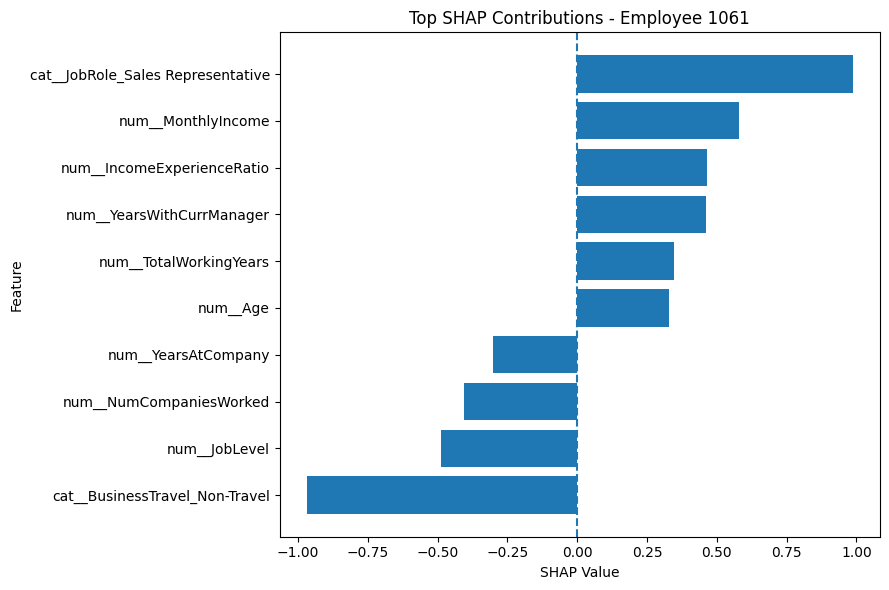

In [141]:
import matplotlib.pyplot as plt

top_shap = employee_shap.head(10).sort_values(
    "SHAP_Value",
    ascending=True
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_shap["Feature"],
    top_shap["SHAP_Value"]
)

plt.axvline(
    x=0,
    linestyle="--"
)

plt.xlabel("SHAP Value")
plt.ylabel("Feature")
plt.title("Top SHAP Contributions - Employee 1061")

plt.tight_layout()
plt.show()

In [142]:
# Save SHAP feature names for Streamlit explainability

shap_metadata = {
    "feature_names": list(feature_names)
}

joblib.dump(
    shap_metadata,
    "../models/shap_metadata.pkl"
)

print("SHAP metadata saved successfully.")

SHAP metadata saved successfully.


In [143]:
import joblib

shap_metadata = {
    "feature_names": list(feature_names)
}

joblib.dump(
    shap_metadata,
    "../models/shap_metadata.pkl"
)

print("SHAP metadata saved successfully.")

SHAP metadata saved successfully.


In [144]:
joblib.dump(
    explainer,
    "../models/shap_explainer.pkl"
)

print("SHAP explainer saved successfully.")

SHAP explainer saved successfully.


In [145]:
import os

print(
    "SHAP metadata exists:",
    os.path.exists("../models/shap_metadata.pkl")
)

print(
    "SHAP explainer exists:",
    os.path.exists("../models/shap_explainer.pkl")
)

SHAP metadata exists: True
SHAP explainer exists: True


In [146]:
import joblib

shap_metadata = {
    "feature_names": list(feature_names)
}

joblib.dump(
    shap_metadata,
    "../models/shap_metadata.pkl"
)

print("SHAP metadata saved successfully.")

SHAP metadata saved successfully.


In [147]:
joblib.dump(
    explainer,
    "../models/shap_explainer.pkl"
)

print("SHAP explainer saved successfully.")

SHAP explainer saved successfully.


In [148]:
import os

print(
    "SHAP metadata exists:",
    os.path.exists("../models/shap_metadata.pkl")
)

print(
    "SHAP explainer exists:",
    os.path.exists("../models/shap_explainer.pkl")
)

SHAP metadata exists: True
SHAP explainer exists: True
